Import packages and define data

In [3]:
import tensorflow as tf
import numpy as np
import unicodedata
import re
import time


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
path="/content/drive/MyDrive/AITest/dataset_chatbot_travel_v2.xlsx"
#data= pandas.read_csv(filepath_or_buffer=path,usecols=['cauhoi','traloi'])
data = pd.read_excel(path)
data.head(5)

,cauhoi,entity_cauhoi,request_cauhoi,traloi,traloimau
0,Đặc sản ở đảo Phú Quý là gì?,Đảo Phú Quý,hỏi về đặc sản,"Đặc sản nổi bật ở Đảo Phú Quý là Cua huỳnh đế,...","Cua huỳnh đế, gỏi ốc giác và nhum nướng mỡ hàn..."
1,Đảo Phú Quý nằm ở đâu?,Đảo Phú Quý,hỏi về vị trí,"Đảo Phú Quý tọa lạc tại Huyện đảo Phú Quý, Tỉn...","Vị trí của Đảo Phú Quý là ở Huyện đảo Phú Quý,..."
2,Đảo Phú Quý thuộc tỉnh nào?,Đảo Phú Quý,hỏi về tỉnh thành,Đảo Phú Quý thuộc Tỉnh Bình Thuận ạ.,Huyện đảo Phú Quý này nằm trong Tỉnh Bình Thuận.
3,Vẻ đẹp nổi bật của Đảo Phú Quý là gì?,Đảo Phú Quý,hỏi về vẻ đẹp,"Đảo Phú Quý sở hữu vẻ đẹp hoang sơ, nước biển ...",Đảo Phú Quý nổi bật với vẻ đẹp hoang sơ và làn...
4,Những hoạt động du lịch nào có thể trải nghiệm...,Đảo Phú Quý,hỏi về hoạt động,"Ở Đảo Phú Quý, bạn có thể trải nghiệm lặn biển...","Bạn có thể lặn biển ngắm san hô, chèo sup và t..."


In [6]:
#!pip install pyvi
#from pyvi import ViTokenizer
##### Câu hỏi
data_cauhoi = []
for tach1 in data['cauhoi']:
        #tachtu1 = ViTokenizer.tokenize(tach1)
        #data_cauhoi.append(tachtu1)
        data_cauhoi.append(tach1)
#print(data_cauhoi)
##### Trả lời
data_traloi = []
for tach2 in data['traloi']:
        #tachtu2 = ViTokenizer.tokenize(tach2)
        #data_traloi.append(tachtu2)
        data_traloi.append(tach2)
#print(data_traloi)

Preprocessing

In [7]:
# Hàm chuyển chữ thường
def normalize_string(text):
    text = re.sub(r"\'ll", " \'ll", text)
    return text.strip().lower()

#raw_data_en, raw_data_fr = list(zip(*raw_data))
#raw_data_en, raw_data_fr = list(raw_data_en), list(raw_data_fr)
raw_data_cauhoi = [normalize_string(data) for data in data_cauhoi]
raw_data_traloi_in = ['<start> ' + normalize_string(data) for data in data_traloi]
raw_data_traloi_out = [normalize_string(data) + ' <end>' for data in data_traloi]

Tokenization

In [8]:
MAX_LEN_CAUHOI = 60
MAX_LEN_TRALOI = 120

cauhoi_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
cauhoi_tokenizer.fit_on_texts(raw_data_cauhoi)
data_cauhoi = cauhoi_tokenizer.texts_to_sequences(raw_data_cauhoi)
data_cauhoi = tf.keras.preprocessing.sequence.pad_sequences(data_cauhoi,
                                                        padding='post',maxlen=MAX_LEN_CAUHOI)

traloi_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
traloi_tokenizer.fit_on_texts(raw_data_traloi_in)
traloi_tokenizer.fit_on_texts(raw_data_traloi_out)
data_traloi_in = traloi_tokenizer.texts_to_sequences(raw_data_traloi_in)
data_traloi_in = tf.keras.preprocessing.sequence.pad_sequences(data_traloi_in,
                                                           padding='post',maxlen=MAX_LEN_TRALOI)

data_traloi_out = traloi_tokenizer.texts_to_sequences(raw_data_traloi_out)
data_traloi_out = tf.keras.preprocessing.sequence.pad_sequences(data_traloi_out,
                                                            padding='post',maxlen=MAX_LEN_TRALOI)

Create tf.data.Dataset object

In [9]:
num_samples = len(data_cauhoi)

SHUFFLE_BUFFER_SIZE = num_samples
BATCH_SIZE = 64
dataset = tf.data.Dataset.from_tensor_slices(
    (data_cauhoi, data_traloi_in, data_traloi_out))
dataset = dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)

Create the Positional Embedding

In [12]:
def positional_embedding(pos, model_size):
    PE = np.zeros((1, model_size))
    for i in range(model_size):
        if i % 2 == 0:
            PE[:, i] = np.sin(pos / 10000 ** (i / model_size))
        else:
            PE[:, i] = np.cos(pos / 10000 ** ((i - 1) / model_size))
    return PE

max_length = max(len(data_cauhoi[0]), len(data_traloi_in[0]))
MODEL_SIZE = 128

pes = []
for i in range(max_length):
    pes.append(positional_embedding(i, MODEL_SIZE))

pes = np.concatenate(pes, axis=0)
pes = tf.constant(pes, dtype=tf.float32)

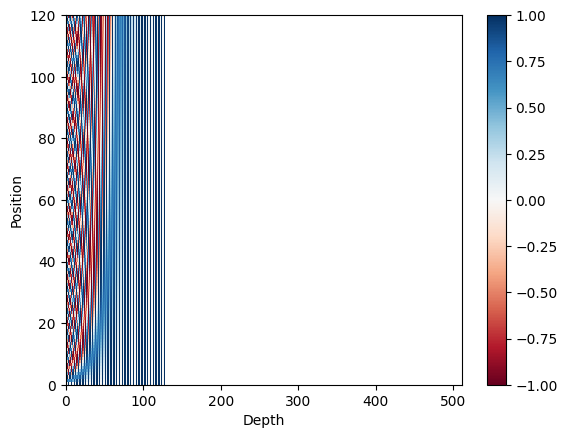

In [13]:
#pos_encoding = positional_embedding(50, 512)
import matplotlib.pyplot as plt
plt.pcolormesh(pes, cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## Create the Multihead Attention layer

In [14]:
class MultiHeadAttention(tf.keras.Model):
    def __init__(self, model_size, h):
        super(MultiHeadAttention, self).__init__()
        self.query_size = model_size // h
        self.key_size = model_size // h
        self.value_size = model_size // h
        self.h = h
        self.wq = [tf.keras.layers.Dense(self.query_size) for _ in range(h)]
        self.wk = [tf.keras.layers.Dense(self.key_size) for _ in range(h)]
        self.wv = [tf.keras.layers.Dense(self.value_size) for _ in range(h)]
        self.wo = tf.keras.layers.Dense(model_size)

    def call(self, decoder_output, encoder_output):
        # decoder_output has shape (batch, decoder_len, model_size)
        # encoder_output has shape (batch, encoder_len, model_size)
        heads = []
        for i in range(self.h):
            score = tf.matmul(self.wq[i](decoder_output), self.wk[i](encoder_output), transpose_b=True) / tf.math.sqrt(tf.dtypes.cast(self.key_size, tf.float32))
            # score has shape (batch, decoder_len, encoder_len)
            alignment = tf.nn.softmax(score, axis=2)
            # alignment has shape (batch, decoder_len, encoder_len)
            head = tf.matmul(alignment, self.wv[i](encoder_output))
            # head has shape (batch, decoder_len, value_size)
            heads.append(head)
        heads = tf.concat(heads, axis=2)
        heads = self.wo(heads)
        # heads has shape (batch, decoder_len, model_size)
        return heads

### Create the Encoder

In [16]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, model_size, num_layers, h):
        super(Encoder, self).__init__()
        self.model_size = model_size
        self.num_layers = num_layers
        self.h = h
        self.embedding = tf.keras.layers.Embedding(vocab_size, model_size)
        self.attention = [MultiHeadAttention(model_size, h) for _ in range(num_layers)]

        self.attention_norm = [tf.keras.layers.BatchNormalization() for _ in range(num_layers)]

        self.dense_1 = [tf.keras.layers.Dense(512, activation='relu') for _ in range(num_layers)]
        self.dense_2 = [tf.keras.layers.Dense(model_size) for _ in range(num_layers)]
        self.ffn_norm = [tf.keras.layers.BatchNormalization() for _ in range(num_layers)]

    def call(self, sequence):
        sub_in = []
        for i in range(sequence.shape[1]):
            embed = self.embedding(tf.expand_dims(sequence[:, i], axis=1))
            sub_in.append(embed + pes[i, :])

        sub_in = tf.concat(sub_in, axis=1)

        for i in range(self.num_layers):
            sub_out = []
            for j in range(sub_in.shape[1]):
                attention = self.attention[i](
                    tf.expand_dims(sub_in[:, j, :], axis=1), sub_in)

                sub_out.append(attention)

            sub_out = tf.concat(sub_out, axis=1)
            sub_out = sub_in + sub_out
            sub_out = self.attention_norm[i](sub_out)

            ffn_in = sub_out

            ffn_out = self.dense_2[i](self.dense_1[i](ffn_in))
            ffn_out = ffn_in + ffn_out
            ffn_out = self.ffn_norm[i](ffn_out)

            sub_in = ffn_out

        return ffn_out

### Create the Decoder

In [17]:
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, model_size, num_layers, h):
        super(Decoder, self).__init__()
        self.model_size = model_size
        self.num_layers = num_layers
        self.h = h
        self.embedding = tf.keras.layers.Embedding(vocab_size, model_size)
        self.attention_bot = [MultiHeadAttention(model_size, h) for _ in range(num_layers)]
        self.attention_bot_norm = [tf.keras.layers.BatchNormalization() for _ in range(num_layers)]
        self.attention_mid = [MultiHeadAttention(model_size, h) for _ in range(num_layers)]
        self.attention_mid_norm = [tf.keras.layers.BatchNormalization() for _ in range(num_layers)]

        self.dense_1 = [tf.keras.layers.Dense(512, activation='relu') for _ in range(num_layers)]
        self.dense_2 = [tf.keras.layers.Dense(model_size) for _ in range(num_layers)]
        self.ffn_norm = [tf.keras.layers.BatchNormalization() for _ in range(num_layers)]

        self.dense = tf.keras.layers.Dense(vocab_size)

    def call(self, sequence, encoder_output):
        # EMBEDDING AND POSITIONAL EMBEDDING
        embed_out = self.embedding(sequence) # shape: (batch, sequence_len, model_size)
        embed_out = embed_out + pes[:tf.shape(sequence)[1], :] # Add positional encoding


        bot_sub_in = embed_out

        for i in range(self.num_layers):
            # BOTTOM MULTIHEAD SUB LAYER
            bot_sub_out = []

            for j in range(bot_sub_in.shape[1]):
                values = bot_sub_in[:, :j, :]
                attention = self.attention_bot[i](
                    tf.expand_dims(bot_sub_in[:, j, :], axis=1), values)

                bot_sub_out.append(attention)
            bot_sub_out = tf.concat(bot_sub_out, axis=1)
            bot_sub_out = bot_sub_in + bot_sub_out
            bot_sub_out = self.attention_bot_norm[i](bot_sub_out)

            # MIDDLE MULTIHEAD SUB LAYER
            mid_sub_in = bot_sub_out

            mid_sub_out = []
            for j in range(mid_sub_in.shape[1]):
                attention = self.attention_mid[i](
                    tf.expand_dims(mid_sub_in[:, j, :], axis=1), encoder_output)

                mid_sub_out.append(attention)

            mid_sub_out = tf.concat(mid_sub_out, axis=1)
            mid_sub_out = mid_sub_out + mid_sub_in
            mid_sub_out = self.attention_mid_norm[i](mid_sub_out)

            # FFN
            ffn_in = mid_sub_out

            ffn_out = self.dense_2[i](self.dense_1[i](ffn_in))
            ffn_out = ffn_out + ffn_in
            ffn_out = self.ffn_norm[i](ffn_out)

            bot_sub_in = ffn_out

        logits = self.dense(ffn_out)

        return logits

In [18]:
############################
H = 2
NUM_LAYERS = 2

cauhoi_vocab_size = len(cauhoi_tokenizer.word_index) + 1
encoder = Encoder(cauhoi_vocab_size, MODEL_SIZE, NUM_LAYERS, H)

cauhoi_sequence_in = tf.constant(data_cauhoi[:2])  # Batch size = 2
encoder_output = encoder(cauhoi_sequence_in)

print('Input vocabulary size', cauhoi_vocab_size)
print('Encoder input shape:', cauhoi_sequence_in.shape)  # Sẽ là (2, 30)
print('Encoder output shape:', encoder_output.shape)


# cauhoi_sequence_in = tf.constant([[1, 2, 3, 4, 6, 7, 8, 0, 0, 0],
#                            [1, 2, 3, 4, 6, 7, 8, 0, 0, 0]])
# encoder_output = encoder(cauhoi_sequence_in)

# print('Encoder input shape', cauhoi_sequence_in.shape)
# print('Encoder output shape', encoder_output.shape)

traloi_vocab_size = len(traloi_tokenizer.word_index) + 1
max_len_traloi = data_traloi_in.shape[1]
decoder = Decoder(traloi_vocab_size, MODEL_SIZE, NUM_LAYERS, H)

# traloi_sequence_in = tf.constant([[1, 2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0],
#                            [1, 2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0]])

traloi_sequence_in = tf.constant(data_traloi_in[:2])
decoder_output = decoder(traloi_sequence_in, encoder_output)

print('Target vocabulary size', traloi_vocab_size)
print('Decoder input shape', traloi_sequence_in.shape)
print('Decoder output shape', decoder_output.shape)

Input vocabulary size 1206
Encoder input shape: (2, 60)
Encoder output shape: (2, 60, 128)
Target vocabulary size 2973
Decoder input shape (2, 120)
Decoder output shape (2, 120, 2973)


In [19]:
# Loss Funtion
crossentropy = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True)
def loss_func(targets, logits):
    mask = tf.math.logical_not(tf.math.equal(targets, 0))
    mask = tf.cast(mask, dtype=tf.int64)
    loss = crossentropy(targets, logits, sample_weight=mask)

    return loss

optimizer = tf.keras.optimizers.Adam()

In [20]:
def predict(test_source_text=None):
    if test_source_text is None:
        test_source_text = raw_data_cauhoi[np.random.choice(len(raw_data_cauhoi))]
    print(test_source_text)
    test_source_seq = cauhoi_tokenizer.texts_to_sequences([test_source_text])
    print(test_source_seq)

    cauhoi_output = encoder(tf.constant(test_source_seq))

    de_input = tf.constant([[traloi_tokenizer.word_index['<start>']]], dtype=tf.int64)

    out_words = []

    while True:
        de_output = decoder(de_input, cauhoi_output)
        new_word = tf.expand_dims(tf.argmax(de_output, -1)[:, -1], axis=1)
        out_words.append(traloi_tokenizer.index_word[new_word.numpy()[0][0]])

        de_input = tf.concat((de_input, new_word), axis=-1)

        if out_words[-1] == '<end>' or len(out_words) >= 50:
            break

    print(' '.join(out_words))

In [21]:
@tf.function
def train_step(source_seq, target_seq_in, target_seq_out):
    with tf.GradientTape() as tape:
        encoder_output = encoder(source_seq)

        decoder_output = decoder(target_seq_in, encoder_output)

        loss = loss_func(target_seq_out, decoder_output)

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))

    return loss

In [22]:
class Seq2SeqModel(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, source_seq, target_seq_in):
        encoder_output = self.encoder(source_seq)
        decoder_output = self.decoder(target_seq_in, encoder_output)
        return decoder_output


In [ ]:
# =================================================================
# PHẦN HUẤN LUYỆN VÀ LƯU TRỮ HOÀN CHỈNH
# =================================================================
import os
import time
import pickle
import tensorflow as tf
import json




# --- A. ĐỊNH NGHĨA CÁC ĐƯỜNG DẪN ---

# 1. Đường dẫn LƯU TẠM THỜI trên máy ảo Colab (An toàn và nhanh)
local_checkpoint_dir = './my_seq2seq_chatbot_local'

# 2. Đường dẫn ĐÍCH trên Google Drive
drive_checkpoint_dir = '/content/drive/MyDrive/AITest/AI_Checkpoints/my_seq2seq_chatbot'

# Tạo các thư mục nếu chúng chưa tồn tại
os.makedirs(local_checkpoint_dir, exist_ok=True)
os.makedirs(drive_checkpoint_dir, exist_ok=True)

# 3. Tạo đường dẫn file cụ thể bên trong thư mục CỤC BỘ
local_encoder_path = os.path.join(local_checkpoint_dir, 'encoder_weights.weights.h5')
local_decoder_path = os.path.join(local_checkpoint_dir, 'decoder_weights.weights.h5')
local_encoder_model = os.path.join(local_checkpoint_dir, 'model_encoder_v1.keras')
local_decoder_model = os.path.join(local_checkpoint_dir, 'model_decoder_v1.keras')
local_cauhoi_tokenizer_path = os.path.join(local_checkpoint_dir, 'cauhoi_tokenizer.pkl')
local_traloi_tokenizer_path = os.path.join(local_checkpoint_dir, 'traloi_tokenizer.pkl')




config = {
    "MODEL_SIZE": MODEL_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "NUM_HEADS": H,
    "MAX_LEN_CAUHOI": MAX_LEN_CAUHOI,
    "MAX_LEN_TRALOI": MAX_LEN_TRALOI,
    "BATCH_SIZE": BATCH_SIZE,
    "VOCAB_SIZE_INPUT": cauhoi_vocab_size,
    "VOCAB_SIZE_OUTPUT": traloi_vocab_size
}

with open(os.path.join(local_checkpoint_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)




# --- B. ĐỊNH NGHĨA HÀM HUẤN LUYỆN ---

@tf.function
def train_step(source_seq, target_seq_in, target_seq_out):
    with tf.GradientTape() as tape:
        encoder_output = encoder(source_seq)
        decoder_output = decoder(target_seq_in, encoder_output)
        loss = loss_func(target_seq_out, decoder_output)

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    return loss

# --- C. VÒNG LẶP HUẤN LUYỆN VÀ LƯU TRỮ ĐỊNH KỲ ---

NUM_EPOCHS = 200
start_time = time.time()

print("--- Bắt đầu quá trình huấn luyện ---")
for e in range(NUM_EPOCHS):
    # Giả sử `dataset` đã được tạo ở các bước trước
    for batch, (source_seq, target_seq_in, target_seq_out) in enumerate(dataset.take(-1)):
        loss = train_step(source_seq, target_seq_in, target_seq_out)

    print('Epoch {}/{} - Loss: {:.4f}'.format(e + 1, NUM_EPOCHS, loss.numpy()))
            # (Tùy chọn) Chạy predict để xem thử kết quả
    try:
        predict()
    except Exception as ex:
        print(f"Lỗi khi predict: {ex}")
    # Lưu checkpoint định kỳ sau mỗi 10 epochs
    if (e + 1) % 10 == 0:
        print("-" * 50)
        print(f"Bắt đầu lưu checkpoint cho Epoch {e + 1}...")

        # Bước 1: Lưu vào thư mục CỤC BỘ của Colab
        print(f"  - Đang lưu trọng số vào {local_checkpoint_dir}...")
        encoder.save_weights(local_encoder_path)
        decoder.save_weights(local_decoder_path)
        encoder.save(local_encoder_model)
        decoder.save(local_decoder_model)
        model = Seq2SeqModel(encoder, decoder)
        model.save(os.path.join(local_checkpoint_dir, 'seq2seq_model_v1.keras'))
        # Lưu tokenizer (thay 'tokenizer' bằng tên biến đúng của bạn)
        try:
            # Lưu tokenizer câu hỏi
            with open(local_cauhoi_tokenizer_path, 'wb') as f:
                pickle.dump(cauhoi_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"  - Đã lưu cauhoi_tokenizer vào {local_cauhoi_tokenizer_path}")

            # Lưu tokenizer câu trả lời
            with open(local_traloi_tokenizer_path, 'wb') as f:
                pickle.dump(traloi_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"  - Đã lưu traloi_tokenizer vào {local_traloi_tokenizer_path}")

        except Exception as ex:
            print(f"  - LỖI khi lưu tokenizer: {ex}")

        # Bước 2: Sao chép từ CỤC BỘ sang GOOGLE DRIVE
        print(f"  - Đang sao chép checkpoint vào Google Drive: {drive_checkpoint_dir}...")
        # Dùng lệnh shell `cp` để sao chép toàn bộ nội dung
        !cp -r {local_checkpoint_dir}/* {drive_checkpoint_dir}/

        print(f"✅ Checkpoint cho Epoch {e + 1} đã được lưu thành công vào Google Drive!")
        print("-" * 50)



end_time = time.time()
with open(os.path.join(local_checkpoint_dir, "training_log.txt"), "a") as f:
    f.write(f"Epoch {e+1}: Loss = {loss.numpy():.4f}\n")
print("\n--- Huấn luyện hoàn tất! ---")
print('Tổng thời gian huấn luyện: {:.2f}s'.format(end_time - start_time))

--- Bắt đầu quá trình huấn luyện ---
Epoch 1/200 - Loss: 1.3790
vé vào cổng mũi yến có không?
[[115, 19, 155, 6, 94, 1, 2]]
có ạ, ạ, có có có có có có có có có <end>
Epoch 2/200 - Loss: 1.3585
dinh vạn thủy tú thuộc phường nào của phan thiết?
[[99, 106, 88, 123, 137, 345, 5, 28, 11, 299]]
có ạ, có có có có có có có có có có có có có có có có có có có có <end>
Epoch 3/200 - Loss: 1.3254
ừm...
[[818]]
có ạ, có có có có có có thể có thể có thể có thể có thể du du các các các các các các các các <end>
Epoch 4/200 - Loss: 1.4903
bạn nói lại được không?
[[35, 260, 160, 67, 2]]
có ạ, các có có một một một một một một các các các các các các các các các các các các các <end>
Epoch 5/200 - Loss: 1.1837
tháp nước phan thiết có đường hầm nào không?
[[32, 27, 11, 43, 1, 152, 1021, 5, 2]]
có ạ, biển biển khu khu khu các bãi biển bãi biển các các các các các các các các các các các các các các các các hợp <end>
Epoch 6/200 - Loss: 1.2616
coco beach camp có phù hợp cho gia đình có trẻ nhỏ không?
[[10

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


  - Đã lưu cauhoi_tokenizer vào ./my_seq2seq_chatbot_local/cauhoi_tokenizer.pkl
  - Đã lưu traloi_tokenizer vào ./my_seq2seq_chatbot_local/traloi_tokenizer.pkl
  - Đang sao chép checkpoint vào Google Drive: /content/drive/MyDrive/AITest/AI_Checkpoints/my_seq2seq_chatbot...
✅ Checkpoint cho Epoch 10 đã được lưu thành công vào Google Drive!
--------------------------------------------------
Epoch 11/200 - Loss: 0.6584
món ăn nào được gợi ý nên thử khi đến đồi cát bay mũi né?
[[412, 104, 5, 67, 343, 71, 37, 344, 44, 39, 23, 25, 58, 6, 327]]
bạn có thể mua áo thoải mái, có thể đi bánh bánh bánh bánh bánh chế đồ ăn bánh bánh bánh chế đồ chế bánh bánh nắng. <end>
Epoch 12/200 - Loss: 0.5791
hoạt động phổ biến nhất ở đồi cát bay mũi né là gì?
[[138, 131, 467, 468, 201, 3, 23, 25, 58, 6, 18, 9, 15]]
giá ở cát ở cát có một đường theo màu trắng tốc trượt cát nhất và đi xe đi xe đi đi đi đi chân ở mũi né ở cát trượt trượt trượt ở các hình trượt ở đồi trắng bị mòn cho thuê đi đi và ở ở ở
Epoch 13/

In [ ]:
import pickle

drive_base_path = '/content/drive/MyDrive/AITest/AI_Checkpoints'
model_checkpoint_folder = 'my_seq2seq_chatbot'
checkpoint_dir = os.path.join(drive_base_path, model_checkpoint_folder)

# Tạo thư mục nếu chưa có
os.makedirs(checkpoint_dir, exist_ok=True)

# Đường dẫn trọng số
encoder_checkpoint_path = os.path.join(checkpoint_dir, 'encoder_weights.weights.h5')
decoder_checkpoint_path = os.path.join(checkpoint_dir, 'decoder_weights.weights.h5')
tokenizer_save_path = os.path.join(checkpoint_dir, 'tokenizer.pkl')
encoder.save_weights(encoder_checkpoint_path)
decoder.save_weights(decoder_checkpoint_path)
try:
    with open(tokenizer_save_path, 'wb') as f:
        pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"--- Đã lưu thành công tokenizer vào: {tokenizer_save_path} ---")
except Exception as e:
    print(f"--- Lỗi khi lưu tokenizer: {e} ---")
print("✅ Đã lưu trọng số vào Google Drive!")


✅ Đã lưu trọng số vào Google Drive!


In [ ]:
def predict1(test_source_text=None):
    import numpy as np

    # Nếu không có đầu vào, chọn ngẫu nhiên một câu hỏi trong tập
    if test_source_text is None:
        test_source_text = raw_data_cauhoi[np.random.choice(len(raw_data_cauhoi))]
    print(f"\n👉 Câu hỏi: {test_source_text}")

    # Mã hóa & pad câu hỏi đầu vào
    test_source_seq = cauhoi_tokenizer.texts_to_sequences([test_source_text])
    test_source_seq = tf.keras.preprocessing.sequence.pad_sequences(
        test_source_seq, maxlen=MAX_LEN_CAUHOI, padding='post'
    )
    print(f"Mã hóa input: {test_source_seq.tolist()}")

    # Gọi encoder để lấy ngữ cảnh
    cauhoi_output = encoder(tf.constant(test_source_seq))

    # Bắt đầu câu trả lời bằng token <start>
    start_token = traloi_tokenizer.word_index.get('<start>', 1)
    end_token = traloi_tokenizer.word_index.get('<end>', 2)

    de_input = tf.constant([[start_token]], dtype=tf.int64)
    out_words = []

    for _ in range(MAX_LEN_TRALOI):
        de_output = decoder(de_input, cauhoi_output)              # (batch, seq_len, vocab_size)
        last_step = de_output[:, -1, :]                           # (batch, vocab_size)
        new_word_id = tf.argmax(last_step, axis=-1).numpy()[0]   # lấy từ có xác suất cao nhất

        # Nếu token nằm ngoài từ điển → bỏ qua
        next_word = traloi_tokenizer.index_word.get(new_word_id, '<unk>')
        if next_word == '<end>':
            break
        out_words.append(next_word)

        # Cập nhật input cho decoder vòng sau
        new_word_tensor = tf.expand_dims([new_word_id], axis=0)  # (1, 1)
        de_input = tf.concat([de_input, new_word_tensor], axis=-1)

    print(f"\n🤖 Chatbot trả lời: {' '.join(out_words)}")


In [ ]:
try:
  predict("về đảo phú quý")
except:
  print("xin lỗi vì sự bất tiện này, quý khách vui lòng để lại thông tin, bên em sẽ liên hệ hỗ trợ ạ ")

về đảo phú quý
[[2]]
bạn có thể tìm thấy bãi biển đồi dương tại trung tâm thành phố phan thiết, như làng chài mũi né, được mua hải sản sớm. <end>
